# Exercises for Thursday afternoon

In this exercise you will perform a complete calculation for approximating time dependent expectation values of the form 

$$O(t) = \langle\Psi_0\lvert \hat{O}(t)\rvert \Psi_0\rangle = \langle\Psi_0\lvert\exp(it\hat{H}) \hat{O}\exp(-it\hat{H})\rvert \Psi_0\rangle$$

With an Ising Hamiltonian given by

$$H=-\sum_{j=0}^{N-1}+J\sum_{j=0}^{N-2}X_jX_{j+1}$$

and an initial state $\rvert \Psi_0\rangle$ obtained from VQE. The goal is to be able to successfully mitigate the systematic errors coming from the noise in the quantum hardware without necessarily worrying too much about the (possibly larger) systematic errors coming from the difference between the actual ground-state of $H$ and our approximation $\rvert \Psi_0\rangle$ and our approximation of the time evolution operator $\exp(-it\hat{H})$. 

Much of what you'll need has been explained and demonstrated in the notebook `ErrorMitigation-Gates` for the case $N=2$ and $J=1$.

This afternoon **your goal is to use instead $N=3$ and $J=2$** and measure the following observables

- $O_0(t)=<Z_0(t)>$, $O_1(t)=<Z_1(t)>$, $O_2(t)=<Z_2(t)>$  
- $O_3(t)=<(Z_0+Z_1+Z_2)(t)>$  
- $O_4(t)=<Z_0Z_1Z_2(t)>$  
- $O_5(t)=<Z_0Z_1(t)>-O_0(t)O_1(t)$  
- $O_6(t)=<Z_0Z_2(t)>-O_0(t)O_2(t)$  
- $O_7(t)=<Z_1Z_2(t)>-O_1(t)O_2(t)$  

The steps are as follows

1. use the simple variational ansatz we used in the morning to determine the optimal rotation angle $\theta$
2. implement the exact time evolution to have a reference (look below if you want to skip this step and use our implementation)
3. implement a second order Trotter approximation of the evolution so that you can benchmark your circuit implementation
4. implement circuits for the second order Trotter approximation of the evolution and verify they are correct using a state vector simulation
5. implement the full protocol of error mitigation (read out and gates) for the circuits you just used at the step above
6. run the circuits with error mitigation on a noise emulator and check they work as expected, if they do run on hardware

Since this is a more challanging simulation than the $N=2$ case explored in the `ErrorMitigation-Gates` notebook we **strongly suggest** to use, as a first step, a simulation where the number of steps is fixed to some values $N_S$ for all times $t$ and you instead change the time-step as $dt=t/N_S$. In this way the error will grow faster in time but at least the depth will be under control. You should try to aim at time intervals like $[0,2]$ or $[0,4]$ with $N_S=4$ and $N_S=8$. Check first how accurate these are compared to a fixed step Trotter evolution and perform a calculation over $20$ time values (for a total of $40$ independent circuits). 

In the latter case, and for the $[0,4]$ time interval, a step $dt=0.1$ is reasonable while with $dt=0.05$ the systematic errors become rather small (but the depth becomes considerably larger...).

-----------------------------------------------------------------------------------------------------------------------

### Exact calculation for reference

First let's define a few useful things below

In [1]:
import numpy as np
import scipy as sp

# we start defining all the Pauli observables we might need
I = np.eye(2)
X = np.array([[0,1],[1,0]],dtype=complex)
Y = np.array([[0,-1.j],[1.j,0]],dtype=complex)
Z = np.array([[1,0],[0,-1]],dtype=complex)
X_2 = np.kron(np.kron(X,I),I); Y_2 = np.kron(np.kron(Y,I),I); Z_2 = np.kron(np.kron(Z,I),I)
X_1 = np.kron(np.kron(I,X),I); Y_1 = np.kron(np.kron(I,Y),I); Z_1 = np.kron(np.kron(I,Z),I)
X_0 = np.kron(np.kron(I,I),X); Y_0 = np.kron(np.kron(I,I),Y); Z_0 = np.kron(np.kron(I,I),Z)

X_0X_1 = np.kron(np.kron(I,X),X); Z_0Z_1 = np.kron(np.kron(I,Z),Z); Z_0Z_2 = np.kron(np.kron(Z,I),Z)
X_1X_2 = np.kron(np.kron(X,X),I); Z_1Z_2 = np.kron(np.kron(Z,Z),I)
X_0X_1X_2 = np.kron(np.kron(X,X),X); Z_0Z_1Z_2 = np.kron(np.kron(Z,Z),Z)
X_0Y_1 = np.kron(np.kron(I,Y),X); X_1Y_2 = np.kron(np.kron(Y,X),I)

## This produces the state \Psi(theta) with the ansatz from thursday morning
def get_initial_state3(theta_angle):
    # these are the computational states
    zero_state=np.array([1,0])
    one_state=np.array([0,1])
    ## exact state prep
    init_state = np.kron(zero_state,np.kron(zero_state,zero_state))
    ## rotation on 01
    r01 = np.cos(theta_angle)*np.eye(8)-1.j*np.sin(theta_angle)*X_0Y_1
    ## rotation on 12
    r12 = np.cos(theta_angle)*np.eye(8)-1.j*np.sin(theta_angle)*X_1Y_2
    ## state
    return r12@r01@init_state

## Returns the energy expectation value for a given input state
def calc_energy3(state,J=1.0):
    H3 = -Z_0-Z_1-Z_2+J*(X_0X_1+X_1X_2)
    return np.real(np.vdot(state,H3@state))
    
## This evolves our initial ansatz state forward in time
## NOTE: 'times' is a list of times we want
def get_evolved_states3(angle, times, J=1.0):
    # get initial state
    init_state = get_initial_state3(angle)
    # get Hamiltonian
    H3 = -Z_0-Z_1-Z_2+J*(X_0X_1+X_1X_2)
    # evolved states
    states = []
    for time in times:
        # exact evolution operator
        propt = sp.linalg.expm(-1.j*time*H3)
        # exact evolved state
        state_of_t = propt@init_state
        # append to list
        states.append(state_of_t)
    return states

## Compute a list of observables an a fixed state
def get_observables(state, obs_list):
    exp_values = []
    for oo in obs_list:
        exp_now = np.real(np.vdot(state,oo@state))
        exp_values.append(exp_now)
    return exp_values

At this point we choose a value for $J$, a value for the angle $\theta$ (which you should optimize yourself) and a list of observables we want to estimate. 

For $J=2$ a value $\theta=-0.5$ is not too bad (you should do better).

In [2]:
## Hamiltonian and state parameters
J_ham = 2.0
theta_angle = -0.5

## Observables
zobs = [Z_0, Z_1, Z_2, Z_0Z_1, Z_1Z_2, Z_0Z_2, Z_0Z_1Z_2]
num_zobs = len(zobs)

## times
num_times = 1000
times = np.linspace(0,4,num_times)

evolved_states = get_evolved_states3(theta_angle,times,J=J_ham)
                                     
zobs_results = np.zeros((num_times,num_zobs))
for rr in range(num_times):
    zobs_results[rr,:] = np.array(get_observables(evolved_states[rr],zobs))

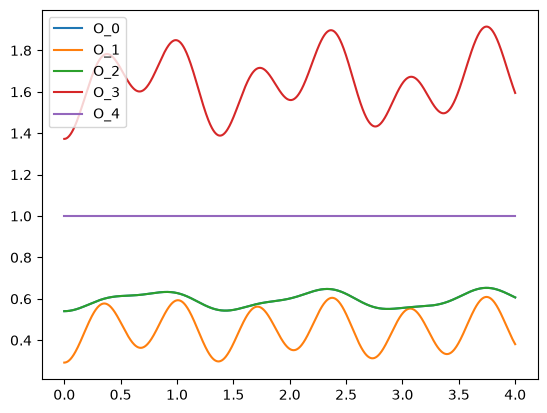

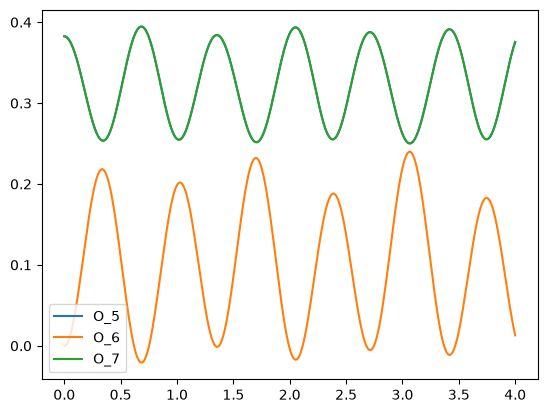

In [3]:
import matplotlib.pyplot as plt

plt.plot(times, zobs_results[:,0], label="O_0")
plt.plot(times, zobs_results[:,1], label="O_1")
plt.plot(times, zobs_results[:,2], label="O_2")
plt.plot(times, zobs_results[:,0]+zobs_results[:,1]+zobs_results[:,2], label="O_3")
plt.plot(times, zobs_results[:,6], label="O_4")
plt.legend()
plt.show()
plt.plot(times, zobs_results[:,3]-zobs_results[:,0]*zobs_results[:,1], label="O_5")
plt.plot(times, zobs_results[:,5]-zobs_results[:,0]*zobs_results[:,2], label="O_6")
plt.plot(times, zobs_results[:,4]-zobs_results[:,1]*zobs_results[:,2], label="O_7")
plt.legend()
plt.show()

-----------------------------------------------------------------------------------------------------------------------
# Solutions

Try to do things on your own before looking at these

### 1. Optimal angle

Minimum energy -4.763284259698092 @ angle = -0.4418356034327988


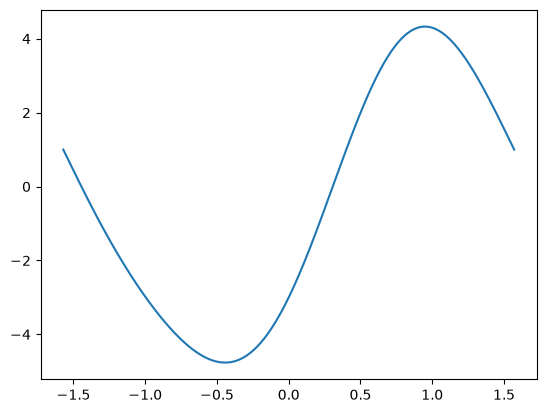

In [4]:
theta_values=np.linspace(-np.pi/2,np.pi/2,1000)
energies = []
for angle in theta_values:
    state_now = get_initial_state3(angle)
    e_now = calc_energy3(state_now,J=J_ham)
    energies.append(e_now)
optimal_angle = theta_values[np.argmin(energies)]
print(f"Minimum energy {np.min(energies)} @ angle = {optimal_angle}")
plt.plot(theta_values,energies)
plt.show()

### 2. Exact reference

In [5]:
## Hamiltonian and state parameters
J_ham = 2.0
theta_angle = optimal_angle

## Observables
zobs = [Z_0, Z_1, Z_2, Z_0Z_1, Z_1Z_2, Z_0Z_2, Z_0Z_1Z_2]
num_zobs = len(zobs)

## times
num_times = 1000
times = np.linspace(0,4,num_times)

evolved_states = get_evolved_states3(theta_angle,times,J=J_ham)
                                     
zobs_results = np.zeros((num_times,num_zobs))
for rr in range(num_times):
    zobs_results[rr,:] = np.array(get_observables(evolved_states[rr],zobs))

### 3. Trotter reference

For our parameters one can do

- OK with dt=0.1 and 40 steps
- VERY WELL with dt=0.05 and 80 steps

In [6]:
def get_trott_evolved_states3(angle, step, num_steps, J=1.0):
    # get initial state
    init_state = get_initial_state3(angle)
    # get Trotter evolution operator
    t_propt_Z =sp.linalg.expm(0.5j*step*(Z_0+Z_1+Z_2))
    t_propt_X =sp.linalg.expm(-1.j*step*J*(X_0X_1+X_1X_2))
    t_propt = t_propt_Z@t_propt_X@t_propt_Z
    # evolved states
    t_states = []
    state_now = init_state.copy()
    for ss in range(num_steps):
        # append to list
        t_states.append(state_now)
        # evolve
        state_now = t_propt@state_now
    return t_states

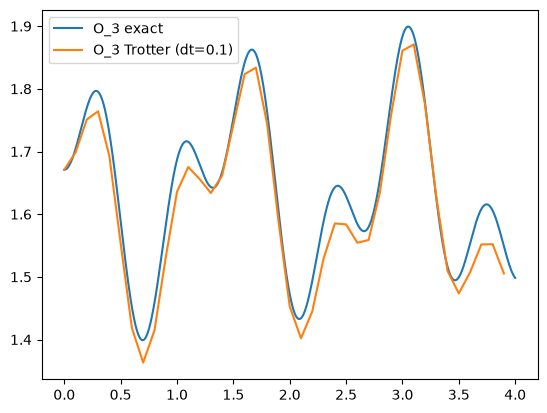

In [7]:
tstep = 0.1
numsteps = 40
trott_times = tstep*np.arange(0,numsteps)

trott_states = get_trott_evolved_states3(optimal_angle,tstep,numsteps,J=J_ham)

trott_zobs_results = np.zeros((numsteps,num_zobs))
for rr in range(numsteps):
    trott_zobs_results[rr,:] = np.array(get_observables(trott_states[rr],zobs))

plt.plot(times, zobs_results[:,0]+zobs_results[:,1]+zobs_results[:,2], label="O_3 exact")
plt.plot(trott_times, trott_zobs_results[:,0]+trott_zobs_results[:,1]+trott_zobs_results[:,2], label="O_3 Trotter (dt=0.1)")
plt.legend()
plt.show()

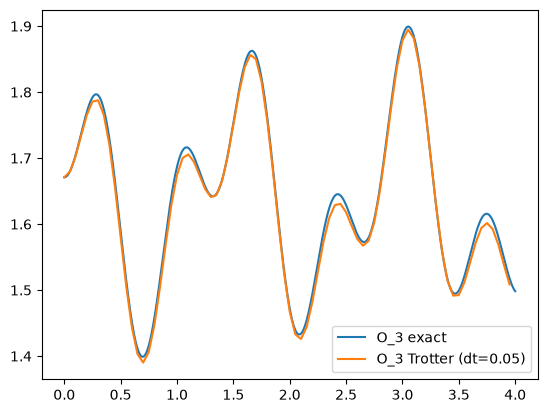

In [8]:
tstep = 0.05
numsteps = 80
trott_times = tstep*np.arange(0,numsteps)

trott_states = get_trott_evolved_states3(optimal_angle,tstep,numsteps,J=J_ham)

trott_zobs_results = np.zeros((numsteps,num_zobs))
for rr in range(numsteps):
    trott_zobs_results[rr,:] = np.array(get_observables(trott_states[rr],zobs))

plt.plot(times, zobs_results[:,0]+zobs_results[:,1]+zobs_results[:,2], label="O_3 exact")
plt.plot(trott_times, trott_zobs_results[:,0]+trott_zobs_results[:,1]+trott_zobs_results[:,2], label="O_3 Trotter (dt=0.05)")
plt.legend()
plt.show()

For the fixed step ones instead we can do the following

In [9]:
## third version where we a fixed number of Trotter steps for different step_sizes
def get_trott_evolved_states3_fixedsteps(angle, step_sizes, trott_steps, J=1.0):
    # evolved states
    t_states = []
    num_steps = len(step_sizes)
    for ss in range(num_steps):
        # get initial state
        state_now = get_initial_state3(angle)
        # get current Trotter evolution operator
        t_propt_Z =sp.linalg.expm(0.5j*step_sizes[ss]*(Z_0+Z_1+Z_2))
        t_propt_X =sp.linalg.expm(-1.j*step_sizes[ss]*J*(X_0X_1+X_1X_2))
        t_propt = t_propt_Z@t_propt_X@t_propt_Z
        # evolve
        for _ in range(trott_steps):
            state_now = t_propt@state_now
        # append to list
        t_states.append(state_now)
    return t_states

In [10]:
nsteps = [4,8]
num_nsteps = len(nsteps)
numsteps = 40
fs_times = np.linspace(0,4.0,numsteps)

tsteps = np.zeros((num_nsteps,numsteps))
fs_trott_zobs_results = np.zeros((num_nsteps,numsteps,num_zobs))

for ns_idx in range(num_nsteps):
    tsteps[ns_idx,:] = fs_times/nsteps[ns_idx]

    fs_trott_states = get_trott_evolved_states3_fixedsteps(optimal_angle,tsteps[ns_idx,:],nsteps[ns_idx],J=J_ham)

    for rr in range(numsteps):
        fs_trott_zobs_results[ns_idx,rr,:] = np.array(get_observables(fs_trott_states[rr],zobs))

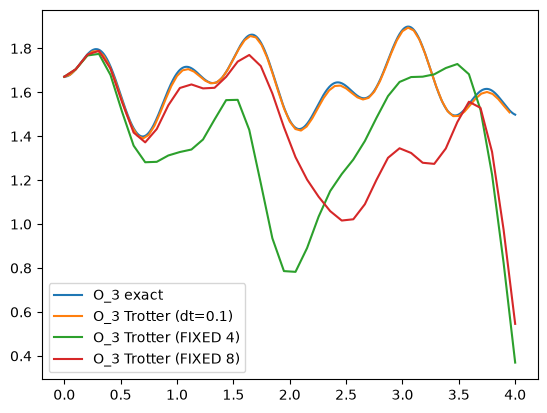

In [11]:
plt.plot(times, zobs_results[:,0]+zobs_results[:,1]+zobs_results[:,2], label="O_3 exact")
plt.plot(trott_times, trott_zobs_results[:,0]+trott_zobs_results[:,1]+trott_zobs_results[:,2], label="O_3 Trotter (dt=0.1)")
plt.plot(fs_times, fs_trott_zobs_results[0,:,0]+fs_trott_zobs_results[0,:,1]+fs_trott_zobs_results[0,:,2], label="O_3 Trotter (FIXED 4)")
plt.plot(fs_times, fs_trott_zobs_results[1,:,0]+fs_trott_zobs_results[1,:,1]+fs_trott_zobs_results[1,:,2], label="O_3 Trotter (FIXED 8)")

plt.legend()
plt.show()

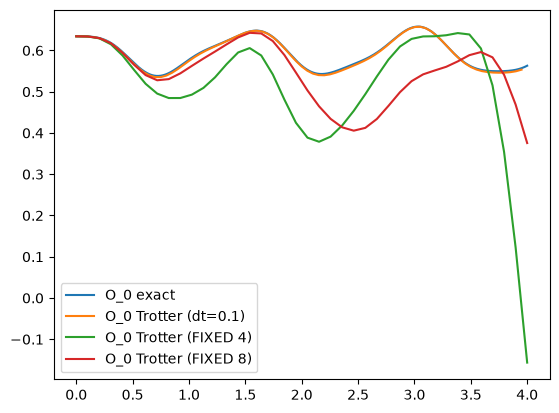

In [12]:
plt.plot(times, zobs_results[:,0], label="O_0 exact")
plt.plot(trott_times, trott_zobs_results[:,0], label="O_0 Trotter (dt=0.1)")
plt.plot(fs_times, fs_trott_zobs_results[0,:,0], label="O_0 Trotter (FIXED 4)")
plt.plot(fs_times, fs_trott_zobs_results[1,:,0], label="O_0 Trotter (FIXED 8)")

plt.legend()
plt.show()

Up to $T=2.0$ these are not too bad and, in addition, have the advantage that the signal changes over a larger codomain so that spotting the differences even with noise should be easier.

### 4. Circuit implementation

Here we start with the fixed depth versions first and then we will look at the more expensive/accurate one

In [13]:
from qiskit import QuantumCircuit

## here we use the rxx gate implemented in qiskit
def add_rXY(circ,angle,a,b):
    circ.sdg(b)
    ## NOTE factor of 2 to comply with qiskit conventions
    circ.rxx(2*angle,a,b)
    circ.s(b)

## state preparation circuit
opt_angle = optimal_angle
state_prep_c = QuantumCircuit(3)
add_rXY(state_prep_c,opt_angle,0,1)
add_rXY(state_prep_c,opt_angle,1,2)

In [14]:
def get_trott_step(tstep, J = 1.0, version = 0):
    if version == 0:
        ## second order Trotter step
        trott_step_c = QuantumCircuit(3)
        ## z evolution for half step
        trott_step_c.rz(-tstep,[0,1,2])
        ## xx evolution for full step
        trott_step_c.h([0,1])
        trott_step_c.cx(0,1)
        trott_step_c.rz(2*J*tstep,1)
        trott_step_c.cx(0,1)
        trott_step_c.h([0,2])
        trott_step_c.cx(2,1)
        trott_step_c.rz(2*J*tstep,1)
        trott_step_c.cx(2,1)
        trott_step_c.h([1,2])
        ## z evolution for half step
        trott_step_c.rz(-tstep,[0,1,2])
        ## barrier to prevent unwanted optimizations
        trott_step_c.barrier()
    elif version == 1:
        ## second order Trotter step [DENSER]
        trott_step_c = QuantumCircuit(3)
        ## z evolution for half step
        trott_step_c.rz(-tstep,[0,1,2])
        ## xx evolution for full step
        trott_step_c.h([0,1,2])
        trott_step_c.cx(1,2)
        trott_step_c.cx(0,1)
        trott_step_c.rz(2*J*tstep,[1,2])
        trott_step_c.cx(0,1)
        trott_step_c.cx(1,2)
        trott_step_c.h([0,1,2])
        ## z evolution for half step
        trott_step_c.rz(-tstep,[0,1,2])
        ## barrier to prevent unwanted optimizations
        trott_step_c.barrier()
    return trott_step_c

def get_fixed_step_circuits(nsteps,opt_angle,J,times_cfs,c_version=0, measure=False):

    if nsteps%2:
        raise Exception("Number of steps needs to be even for this to work properly")
    
    ## retrieve number of times (== number of circuits)
    ntimes_cfs = len(times_cfs)

    ## state preparation circuit
    state_prep_c = QuantumCircuit(3)
    add_rXY(state_prep_c,opt_angle,0,1)
    add_rXY(state_prep_c,opt_angle,1,2)

    # first we do the regular evolution ones
    regular_circs = []
    ## first circuit is at time 0 so we only do state prep
    circ_now = state_prep_c.copy()
    # check if we need to measure (set to False for statevector)
    if measure:
        circ_now.measure_all()
    regular_circs.append(circ_now)
    for cidx in range(ntimes_cfs-1):
        step_now = times_cfs[cidx+1]/nsteps
        # start from state prep
        circ_now = state_prep_c.copy()
        # generate right Trotter step
        c_tstep = get_trott_step(step_now,J=J,version=c_version)
        # now do the steps
        for ss in range(nsteps):
            circ_now.append(c_tstep,[0,1,2])

        # check if we need to measure (set to False for statevector)
        if measure:
            circ_now.measure_all()
        # store circuit
        regular_circs.append(circ_now)

    return regular_circs

In [15]:
### We start with the N_S=4 calculation on [0,2] with 20 time values

ntimes_cfs = 40
tmax = 4.0
times_cfs = np.linspace(0,tmax,ntimes_cfs)
c_version = 1
J=J_ham

circs_ns4 = get_fixed_step_circuits(4, optimal_angle, J_ham, times_cfs, c_version)
circs_ns8 = get_fixed_step_circuits(8, optimal_angle, J_ham, times_cfs, c_version)

all_circs = circs_ns4 + circs_ns8

In [16]:
from qiskit_aer import AerSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit import transpile

## Generate a 3-qubit simulated backend
my_coupling_map = [(0, 1),(1, 2)] 
fake_3qubits = GenericBackendV2(
    num_qubits=3,
    coupling_map=my_coupling_map,
    basis_gates=["id", "rz", "sx", "x", "cz"],
    seed=42 # set a fixed seed for PRNG
)
## transpile for this target
transpiled_trott_circuits = []
for circ in all_circs:
    transpiled = transpile(circ, 
                                backend=fake_3qubits,
                                optimization_level=1,
                                initial_layout=[0,1,2]
                    )
    transpiled_trott_circuits.append(transpiled)

## run them
sim_statevector = AerSimulator(method='statevector')
zobs_4 = np.zeros((ntimes_cfs,num_zobs))
zobs_8 = np.zeros((ntimes_cfs,num_zobs))
for idx,cc in enumerate(transpiled_trott_circuits):
    circ = cc.copy()
    circ.save_statevector()
    job_sv = sim_statevector.run(circ)
    result_sv = job_sv.result()
    outputstate_sv = result_sv.get_statevector(circ, decimals=8)
    npstate = np.array(outputstate_sv.data.tolist())
    for oidx, oo in enumerate(zobs):
        # the first half are for N=4 the second for N=8
        if idx<ntimes_cfs:
            zobs_4[idx][oidx] = np.real(np.vdot(npstate,oo@npstate))
        else:
            zobs_8[idx-ntimes_cfs][oidx] = np.real(np.vdot(npstate,oo@npstate))


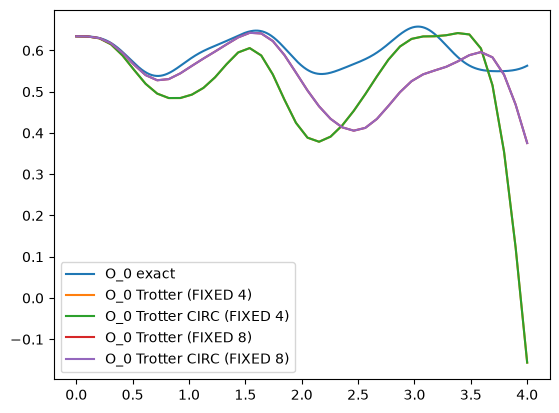

In [17]:
plt.plot(times, zobs_results[:,0], label="O_0 exact")
plt.plot(fs_times, fs_trott_zobs_results[0,:,0], label="O_0 Trotter (FIXED 4)")
plt.plot(times_cfs, zobs_4[:,0], label="O_0 Trotter CIRC (FIXED 4)")
plt.plot(fs_times, fs_trott_zobs_results[1,:,0], label="O_0 Trotter (FIXED 8)")
plt.plot(times_cfs, zobs_8[:,0], label="O_0 Trotter CIRC (FIXED 8)")

plt.legend()
plt.show()

Now we are ready for a test with the noise model

In [18]:
from qiskit_aer.noise import NoiseModel

# for the 3 qubit backend
noise_model3 = NoiseModel.from_backend(fake_3qubits)
sim_noisy3 = AerSimulator(noise_model=noise_model3,target=fake_3qubits)

In [19]:
### We start with the N_S=4 calculation on [0,2] with 20 time values

ntimes_cfs = 40
tmax = 4.0
times_cfs = np.linspace(0,tmax,ntimes_cfs)
c_version = 1
J=J_ham

circs_ns4_qasm = get_fixed_step_circuits(4, optimal_angle, J_ham, times_cfs, c_version, measure=True)
circs_ns8_qasm = get_fixed_step_circuits(8, optimal_angle, J_ham, times_cfs, c_version, measure=True)

all_circs_qasm = circs_ns4_qasm + circs_ns8_qasm

## transpile for this target
transpiled_trott_circuits = []
for circ in all_circs_qasm:
    transpiled = transpile(circ, 
                                backend=fake_3qubits,
                                optimization_level=1,
                                initial_layout=[0,1,2]
                    )
    transpiled_trott_circuits.append(transpiled)

## run them
job_noise = sim_noisy3.run(transpiled_trott_circuits, # a list of transipled circuits
               shots=1024, # an integer value
               seed_simulator=42)

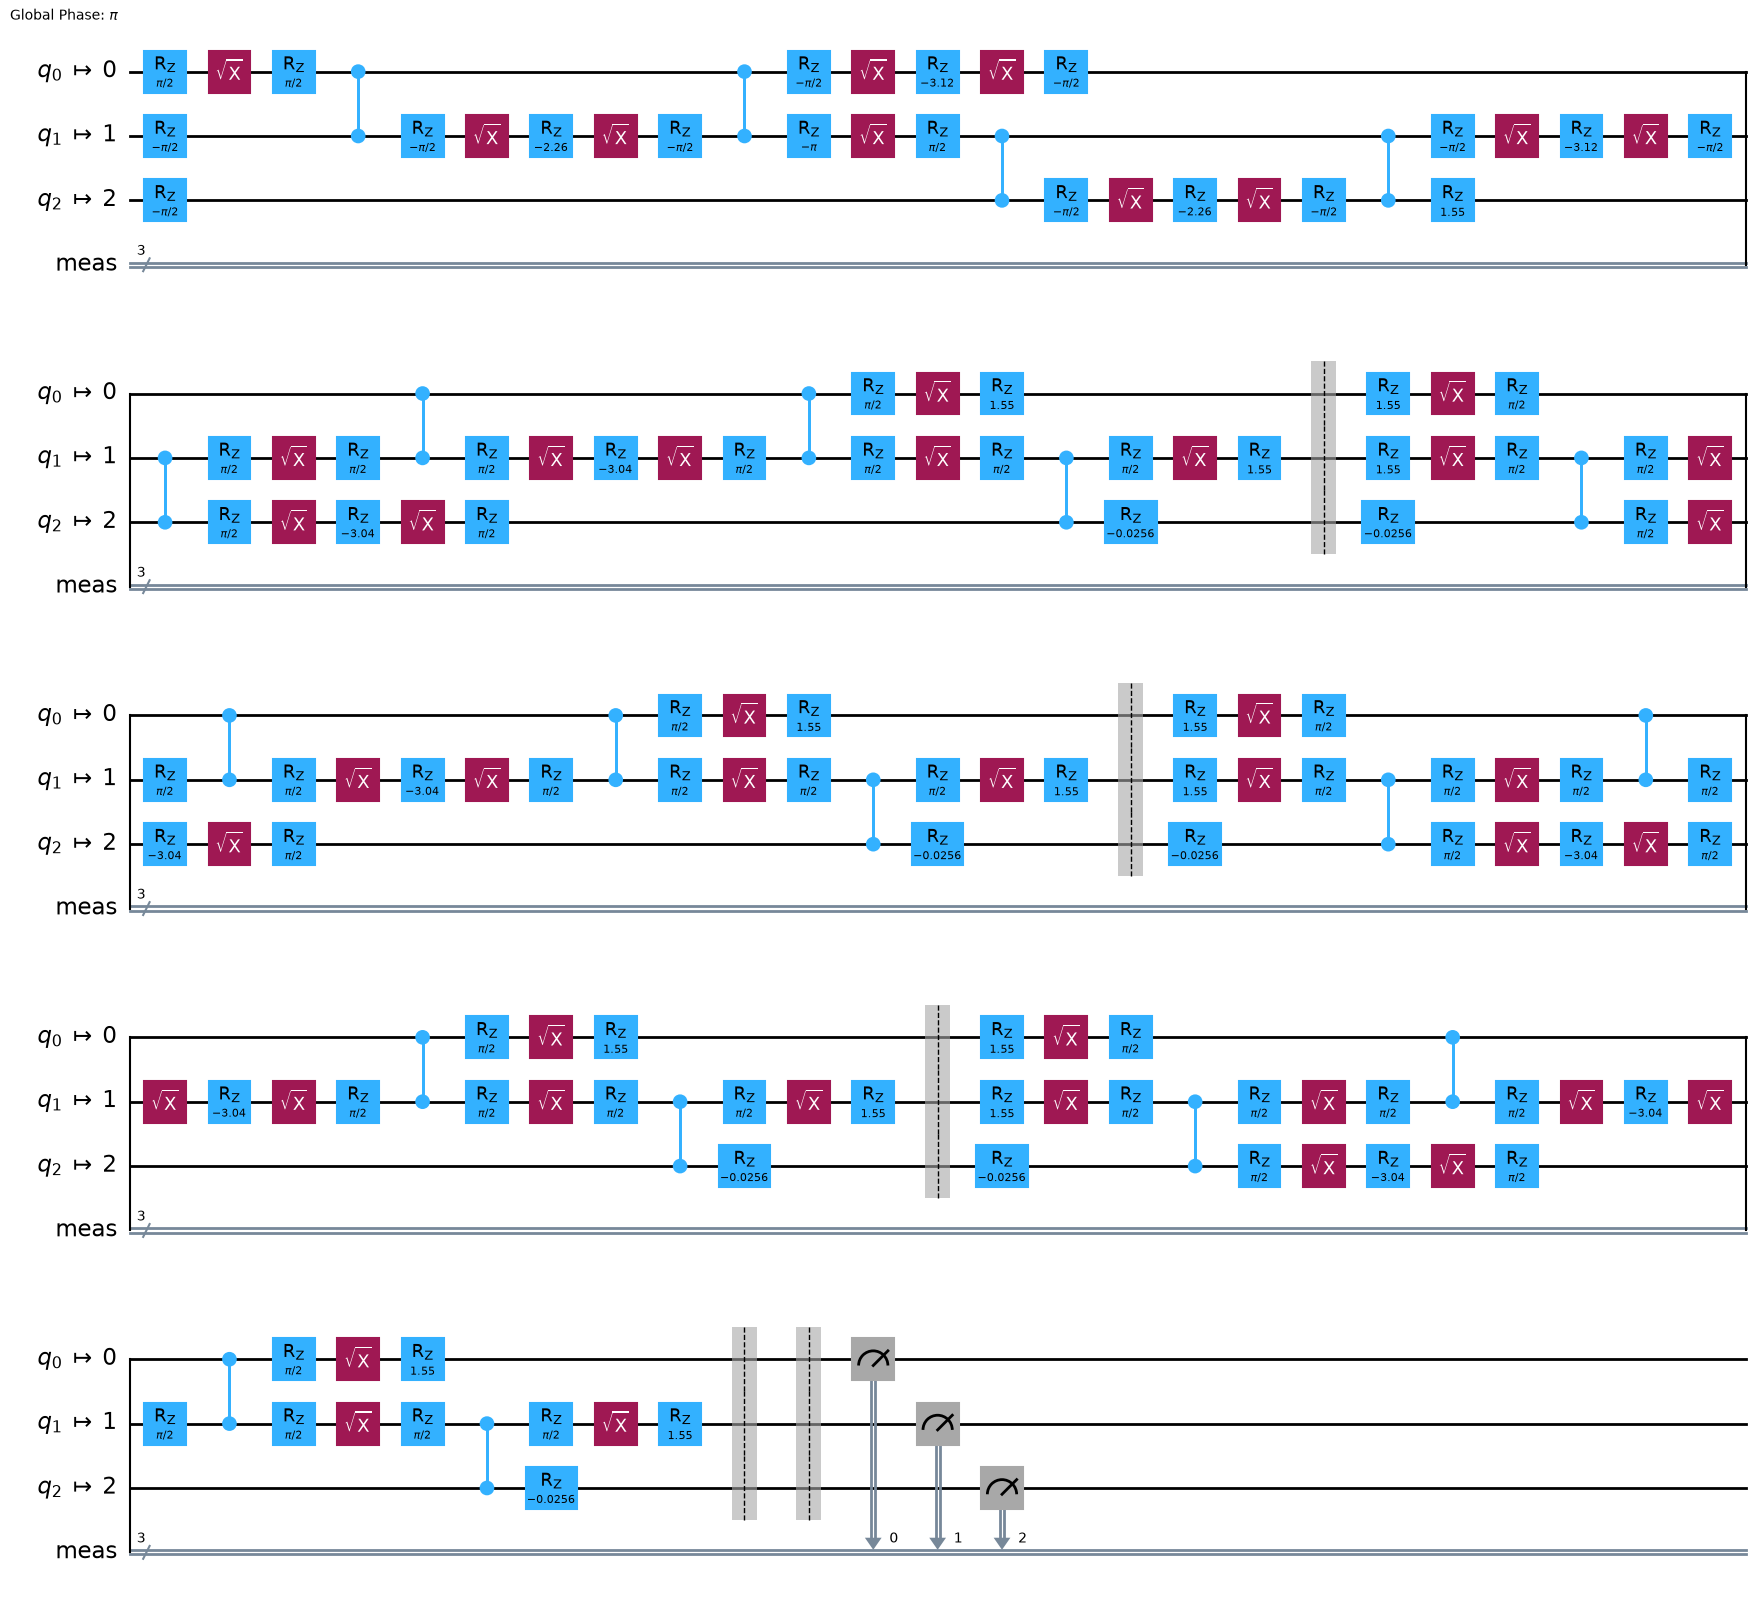

In [20]:
transpiled_trott_circuits[1].draw('mpl')

In [21]:
def exp_err_from_counts(input_counts, bits_for_observable):
    average_obs = 0.0
    err_obs = 0.0
    tot_counts = 0
    for cc in input_counts:
        ## convert the measured bit-string into a list of numerical values
        int_bit_string = [int(bb) for bb in cc]
        ## compute the sum of bits (note the ordering convention)
        num_qubits = len(int_bit_string)
        exp_sum = sum([int_bit_string[num_qubits-1-bit] for bit in bits_for_observable])
        ## convert this into the corresponding value
        value = (-1)**exp_sum
        ## and accumulate the result by multiplying the number of counts
        average_obs += input_counts[cc]*value
        ## together with the cumulative number of counts
        tot_counts += input_counts[cc]
    ## we finish by dividing by the total number of counts
    average_obs /= tot_counts
    ## estimate error
    err_obs = np.sqrt((1.-average_obs**2)/(tot_counts-1))
    return average_obs, err_obs
    
# here we only feed counts for a fixed run (ie. only N_S=4 or N_S=8)
def observables_from_counts_raw(counts,ntimes_cfs):

    ## check we have the right number of counts
    if len(counts) != ntimes_cfs:
        raise Exception("The number of counts does not seem to match!")
        
    num_zobs = 7
    zobs_qasm = np.zeros((ntimes_cfs,num_zobs))
    err_zobs_qasm = np.zeros((ntimes_cfs,num_zobs))
    
    for tidx in range(ntimes_cfs):
        ## Z_0
        z0,ez0 = exp_err_from_counts(counts[tidx],[0])
        zobs_qasm[tidx,0] = z0
        err_zobs_qasm[tidx,0] = ez0        
        ## Z_1
        z1,ez1 = exp_err_from_counts(counts[tidx],[1])
        zobs_qasm[tidx,1] = z1
        err_zobs_qasm[tidx,1] = ez1        
        ## Z_2
        z2,ez2 = exp_err_from_counts(counts[tidx],[2])
        zobs_qasm[tidx,2] = z2
        err_zobs_qasm[tidx,2] = ez2        
        ## Z_0Z_1
        z01,ez01 = exp_err_from_counts(counts[tidx],[0,1])
        zobs_qasm[tidx,3] = z01
        err_zobs_qasm[tidx,3] = ez01        
        ## Z_1Z_2
        z12,ez12 = exp_err_from_counts(counts[tidx],[1,2])
        zobs_qasm[tidx,4] = z12
        err_zobs_qasm[tidx,4] = ez12        
        ## Z_0Z_2
        z02,ez02 = exp_err_from_counts(counts[tidx],[0,2])
        zobs_qasm[tidx,5] = z02
        err_zobs_qasm[tidx,5] = ez02        
        ## Z_0Z_1Z_2
        z012,ez012 = exp_err_from_counts(counts[tidx],[0,1,2])
        zobs_qasm[tidx,6] = z012
        err_zobs_qasm[tidx,6] = ez012        
        
    return zobs_qasm, err_zobs_qasm

In [22]:
counts_noise = job_noise.result().get_counts()

In [23]:
zobs_4_noise, err_zobs_4_noise = observables_from_counts_raw(counts_noise[0:ntimes_cfs],ntimes_cfs)
zobs_8_noise, err_zobs_8_noise = observables_from_counts_raw(counts_noise[ntimes_cfs:],ntimes_cfs)

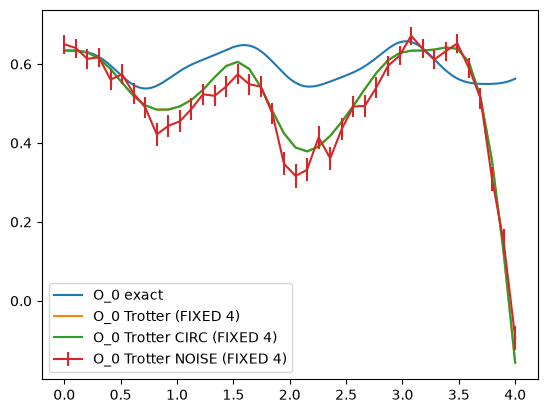

In [24]:
plt.plot(times, zobs_results[:,0], label="O_0 exact")
plt.plot(fs_times, fs_trott_zobs_results[0,:,0], label="O_0 Trotter (FIXED 4)")
plt.plot(times_cfs, zobs_4[:,0], label="O_0 Trotter CIRC (FIXED 4)")
plt.errorbar(times_cfs, zobs_4_noise[:,0], err_zobs_4_noise[:,0], label="O_0 Trotter NOISE (FIXED 4)")

plt.legend()
plt.show()

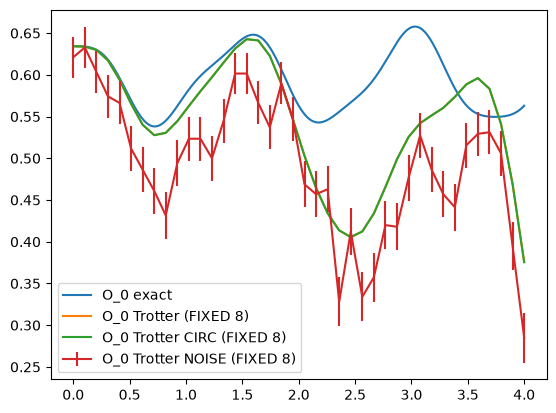

In [25]:
plt.plot(times, zobs_results[:,0], label="O_0 exact")
plt.plot(fs_times, fs_trott_zobs_results[1,:,0], label="O_0 Trotter (FIXED 8)")
plt.plot(times_cfs, zobs_8[:,0], label="O_0 Trotter CIRC (FIXED 8)")
plt.errorbar(times_cfs, zobs_8_noise[:,0], err_zobs_8_noise[:,0], label="O_0 Trotter NOISE (FIXED 8)")

plt.legend()
plt.show()

Let's now do a proper job with error mitigation

### - $N_S = 4$

In [26]:
def get_fixed_step_circuits_with_mit(nsteps,opt_angle,J,times_cfs,c_version=0, measure=False, ro_mit=False, gate_calib=False):

    full_circuit_list = []
    
    ## check if we need to add RO calibration
    if ro_mit:
        ## circuits for read-out calibration
        cal_circuits_simple = []
        ## first one for the 000 string
        cal_circ_000 = QuantumCircuit(3)
        cal_circ_000.measure_all()
        cal_circuits_simple.append(cal_circ_000)
        ## last one for the 111 string
        cal_circ_111 = QuantumCircuit(3)
        cal_circ_111.x(0)
        cal_circ_111.x(1)
        cal_circ_111.x(2)
        cal_circ_111.measure_all()
        cal_circuits_simple.append(cal_circ_111)

        full_circuit_list += cal_circuits_simple
    
    ## retrieve number of times (== number of circuits)
    ntimes_cfs = len(times_cfs)

    ## state preparation circuit
    state_prep_c = QuantumCircuit(3)
    add_rXY(state_prep_c,opt_angle,0,1)
    add_rXY(state_prep_c,opt_angle,1,2)

    # first we do the regular evolution ones
    regular_circs = []
    ## first circuit is at time 0 so we only do state prep
    circ_now = state_prep_c.copy()
    # check if we need to measure (set to False for statevector)
    if measure:
        circ_now.measure_all()
    regular_circs.append(circ_now)
    for cidx in range(ntimes_cfs-1):
        step_now = times_cfs[cidx+1]/nsteps
        # start from state prep
        circ_now = state_prep_c.copy()
        # generate right Trotter step
        c_tstep = get_trott_step(step_now,J=J,version=c_version)
        # now do the steps
        for ss in range(nsteps):
            circ_now.append(c_tstep,[0,1,2])

        # check if we need to measure (set to False for statevector)
        if measure:
            circ_now.measure_all()
        # store circuit
        regular_circs.append(circ_now)

    # append to full list
    full_circuit_list += regular_circs

    if gate_calib:
        if nsteps%2:
            raise Exception("Number of steps needs to be even for this to work properly")

        ## idle state preparation circuit (one possible way of doing it...)
        ### this version prepares |101>
        ### NOTE: with optimization_level = 2 this gets simplified -> check that circuit is the one you want
        id_state_prep_c = QuantumCircuit(3)
        add_rXY(id_state_prep_c,np.pi/2,0,1)
        add_rXY(id_state_prep_c,np.pi/2,1,2)

        ## add reversed evolution
        reversed_circs = []
        ## first circuit is at time 0 so we only do state prep
        circ_now = id_state_prep_c.copy()
        # check if we need to measure (set to False for statevector)
        if measure:
            circ_now.measure_all()
        reversed_circs.append(circ_now)
        for cidx in range(ntimes_cfs-1):
            step_now = times_cfs[cidx+1]/nsteps
            # start from idle state prep
            circ_now = id_state_prep_c.copy()
            # generate right Trotter step
            c_tstep = get_trott_step(step_now,J=J,version=c_version)
            # and its reversed one 
            inv_c_tstep = get_trott_step(-step_now,J=J,version=c_version)
            # do the steps forward for half of them
            for ss in range(nsteps>>1):
                circ_now.append(c_tstep,[0,1,2])
            # now do the steps backward for half of them
            for ss in range(nsteps>>1):
                circ_now.append(inv_c_tstep,[0,1,2])

            # check if we need to measure (set to False for statevector)
            if measure:
                circ_now.measure_all()
            # store circuit
            reversed_circs.append(circ_now)

        # append to full list
        full_circuit_list += reversed_circs
        
    return full_circuit_list

In [27]:
### We start with the N_S=4 calculation on [0,4] with 40 time values

ntimes_cfs = 40
tmax = 4.0
times_cfs = np.linspace(0,tmax,ntimes_cfs)
c_version = 0
J=J_ham

## let's produce bare circuits first
circs_ns4_mit = get_fixed_step_circuits_with_mit(4, optimal_angle, J_ham, times_cfs, c_version, measure=True, ro_mit=True, gate_calib=True)

## transpile for this target
transpiled_trott_circuits_ns4_mit = []
for circ in circs_ns4_mit:
    transpiled = transpile(circ, 
                                backend=fake_3qubits,
                                optimization_level=1,
                                initial_layout=[0,1,2]
                    )
    transpiled_trott_circuits_ns4_mit.append(transpiled)

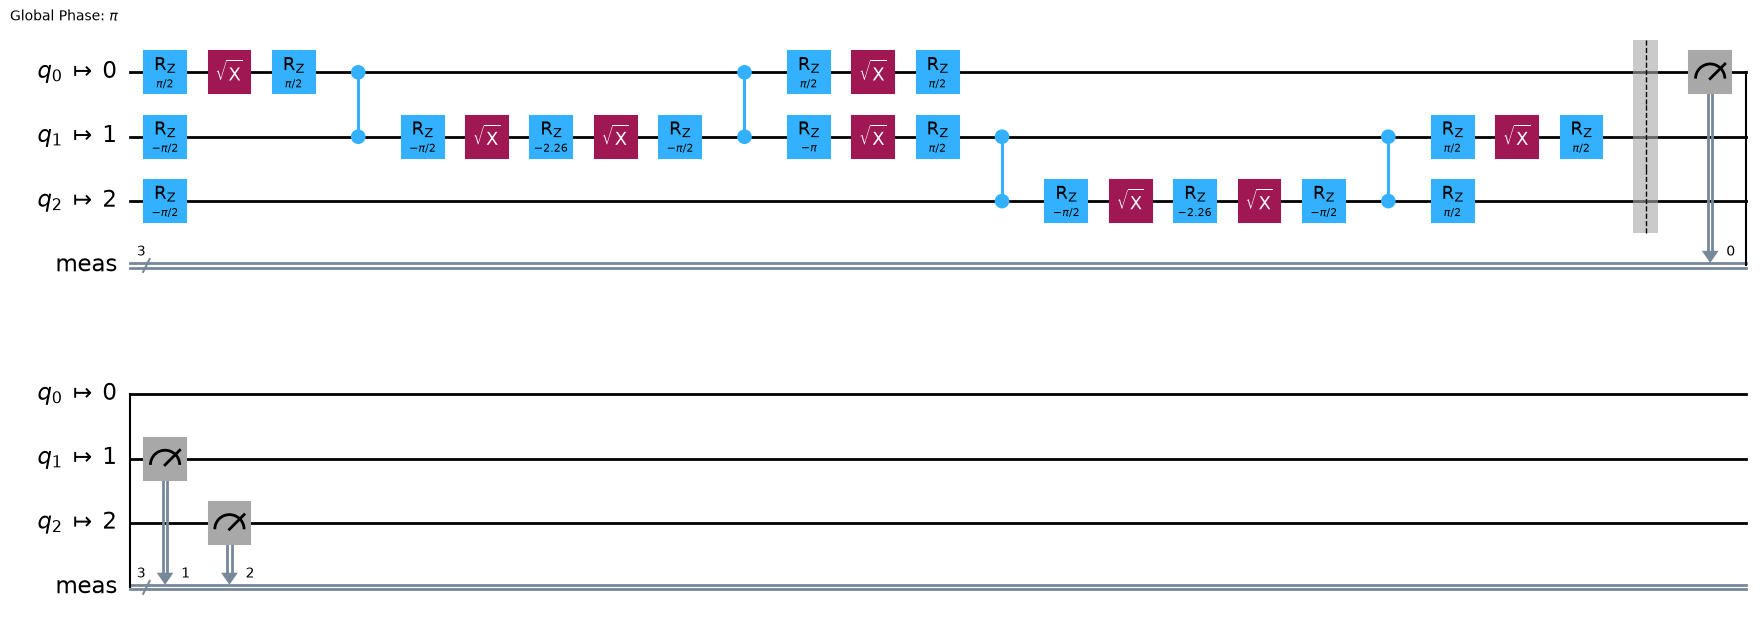

In [28]:
transpiled_trott_circuits_ns4_mit[2].draw('mpl')

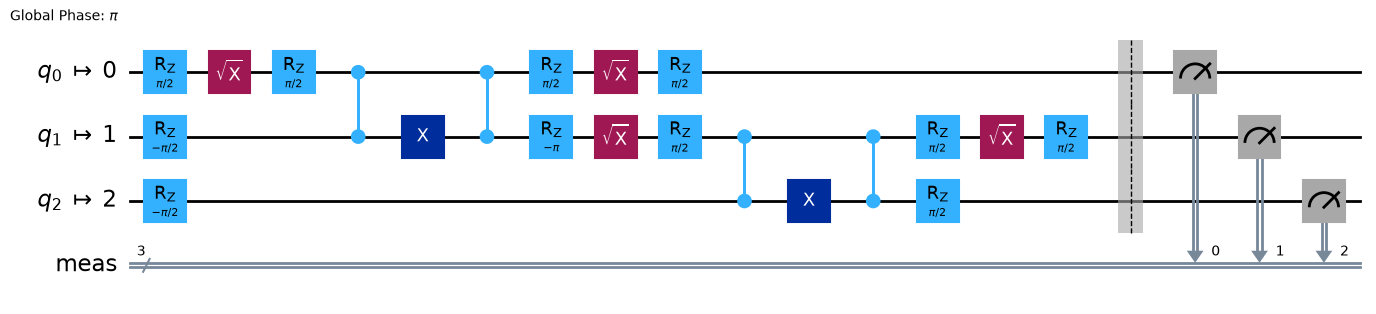

In [29]:
transpiled_trott_circuits_ns4_mit[42].draw('mpl')

In [30]:
from twirl import PauliTwirl
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.transpiler import PassManager

opt_level = 1
initial_layout = [0,1,2]

# define a pass manager for transpilation
pm_fake3 = generate_preset_pass_manager(backend=fake_3qubits, 
                                      target=fake_3qubits.target, 
                                      optimization_level=opt_level, 
                                      initial_layout=initial_layout)

# define a pass manager for Twirling
twirl=PauliTwirl()
pm_twirl = PassManager([twirl])

In [31]:
num_twirls = 20

## transpile for this target with twirling
transpiled_trott_circuits_ns4_mit = []
for circ in circs_ns4_mit:
    current_circuit = circ.copy()
    for _ in range(num_twirls):
        circ_now = pm_fake3.run(current_circuit)
        circ_now = pm_twirl.run(circ_now)
        circ_now = pm_fake3.run(circ_now)
        transpiled_trott_circuits_ns4_mit.append(circ_now)

In [32]:
nshots = 2048//num_twirls ## spread shot budget over all the twirls

## run them
job_noise = sim_noisy3.run(transpiled_trott_circuits_ns4_mit, # a list of transipled circuits
               shots=nshots, # an integer value
               seed_simulator=42)

In [33]:
all_counts_noise = job_noise.result().get_counts()

In [34]:
aggregated_counts = []
## we now aggregate counts for the twirls
for ss in range(ntimes_cfs*2+2):
    counts_now = {}
    for tt in range(num_twirls):
        for kk in all_counts_noise[num_twirls*ss+tt]:
            if kk in counts_now:
                ## increment if present
                counts_now[kk] += all_counts_noise[num_twirls*ss+tt][kk]
            else:
                ## add new if not present
                counts_now[kk] = all_counts_noise[num_twirls*ss+tt][kk]
    aggregated_counts.append(counts_now)

In [35]:
## RO calibration
from error_mit import get_single_qubit_ro_probs, get_mit_counts, fix_negative
## extract calibration matrices
cal_matrices = get_single_qubit_ro_probs(aggregated_counts[0:2])
print(cal_matrices)

_Found 3 qubits in first calibration circuit counts
[array([[9.98039216e-01, 4.90196078e-04],
       [1.96078431e-03, 9.99509804e-01]]), array([[0.99852941, 0.00294118],
       [0.00147059, 0.99705882]]), array([[1.00000000e+00, 4.90196078e-04],
       [0.00000000e+00, 9.99509804e-01]])]


In [36]:
## obtain corrected counts
num_qubits = 3
mit_counts = []
for rc in aggregated_counts:
    mc = get_mit_counts(rc,num_qubits,cal_matrices)
    mit_counts.append(mc)

In [37]:
## extract data from the first half of the runs
zobs_4_noise_ro_tw, err_zobs_4_noise_ro_tw = observables_from_counts_raw(mit_counts[2:2+ntimes_cfs],ntimes_cfs)
## extract calibration data from the second half of the runs
zcal_4_noise_ro_tw, err_zcal_4_noise_ro_tw = observables_from_counts_raw(mit_counts[2+ntimes_cfs:],ntimes_cfs)

In [38]:
### these are the expected, noise free, results for calibration on state |101>
z0_ref = -1
z1_ref = 1
z2_ref = -1
z0z1_ref = -1
z1z2_ref = -1
z0z2_ref = 1
z0z1z2_ref = 1
zcal_ref = np.array([z0_ref,z1_ref,z2_ref,z0z1_ref,z1z2_ref,z0z2_ref,z0z1z2_ref])
dep_fact = zcal_4_noise_ro_tw/zcal_ref

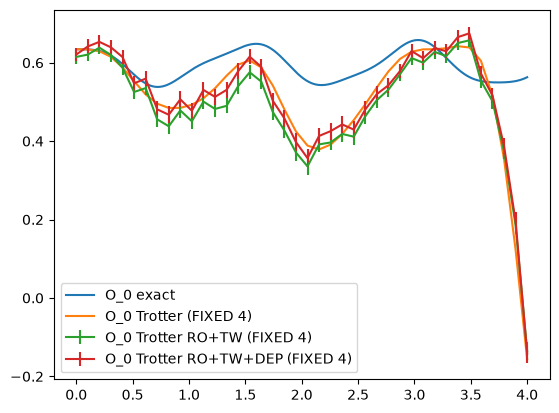

In [39]:
plt.plot(times, zobs_results[:,0], label="O_0 exact")
plt.plot(fs_times, fs_trott_zobs_results[0,:,0], label="O_0 Trotter (FIXED 4)")
#plt.errorbar(times_cfs, zobs_4_noise[:,0], err_zobs_4_noise[:,0], label="O_0 Trotter NOISE (FIXED 4)")
plt.errorbar(times_cfs, zobs_4_noise_ro_tw[:,0], err_zobs_4_noise_ro_tw[:,0], label="O_0 Trotter RO+TW (FIXED 4)")
plt.errorbar(times_cfs, zobs_4_noise_ro_tw[:,0]/dep_fact[:,0], err_zobs_4_noise_ro_tw[:,0]/dep_fact[:,0], label="O_0 Trotter RO+TW+DEP (FIXED 4)")

plt.legend()
plt.show()

### - $N_S = 8$

In [40]:
### Now we do the N_S=8 calculation on [0,4] with 40 time values

ntimes_cfs = 40
tmax = 4.0
times_cfs = np.linspace(0,tmax,ntimes_cfs)
c_version = 0
J=J_ham

## let's produce bare circuits first
circs_ns8_mit = get_fixed_step_circuits_with_mit(8, optimal_angle, J_ham, times_cfs, c_version, measure=True, ro_mit=True, gate_calib=True)

num_twirls = 20

## transpile for this target with twirling
transpiled_trott_circuits_ns8_mit = []
for circ in circs_ns8_mit:
    current_circuit = circ.copy()
    for _ in range(num_twirls):
        circ_now = pm_fake3.run(current_circuit)
        circ_now = pm_twirl.run(circ_now)
        circ_now = pm_fake3.run(circ_now)
        transpiled_trott_circuits_ns8_mit.append(circ_now)

nshots = 2048//num_twirls ## spread shot budget over all the twirls

## run them
job_noise_ns8 = sim_noisy3.run(transpiled_trott_circuits_ns8_mit, # a list of transipled circuits
               shots=nshots, # an integer value
               seed_simulator=42)

In [41]:
## collect counts
all_counts_noise = job_noise_ns8.result().get_counts()

In [42]:
## we now aggregate counts for the twirls
aggregated_counts = []
for ss in range(ntimes_cfs*2+2):
    counts_now = {}
    for tt in range(num_twirls):
        for kk in all_counts_noise[num_twirls*ss+tt]:
            if kk in counts_now:
                ## increment if present
                counts_now[kk] += all_counts_noise[num_twirls*ss+tt][kk]
            else:
                ## add new if not present
                counts_now[kk] = all_counts_noise[num_twirls*ss+tt][kk]
    aggregated_counts.append(counts_now)

## extract calibration matrices
cal_matrices = get_single_qubit_ro_probs(aggregated_counts[0:2])
print(cal_matrices)

## obtain corrected counts
num_qubits = 3
mit_counts = []
for rc in aggregated_counts:
    mc = get_mit_counts(rc,num_qubits,cal_matrices)
    mit_counts.append(mc)

## extract data from the first half of the runs
zobs_8_noise_ro_tw, err_zobs_8_noise_ro_tw = observables_from_counts_raw(mit_counts[2:2+ntimes_cfs],ntimes_cfs)
## extract calibration data from the second half of the runs
zcal_8_noise_ro_tw, err_zcal_8_noise_ro_tw = observables_from_counts_raw(mit_counts[2+ntimes_cfs:],ntimes_cfs)

### these are the expected, noise free, results for calibration on state |101>
z0_ref = -1
z1_ref = 1
z2_ref = -1
z0z1_ref = -1
z1z2_ref = -1
z0z2_ref = 1
z0z1z2_ref = 1
zcal_ref = np.array([z0_ref,z1_ref,z2_ref,z0z1_ref,z1z2_ref,z0z2_ref,z0z1z2_ref])
dep_fact = zcal_8_noise_ro_tw/zcal_ref

_Found 3 qubits in first calibration circuit counts
[array([[9.98039216e-01, 4.90196078e-04],
       [1.96078431e-03, 9.99509804e-01]]), array([[0.99852941, 0.00294118],
       [0.00147059, 0.99705882]]), array([[1.00000000e+00, 4.90196078e-04],
       [0.00000000e+00, 9.99509804e-01]])]


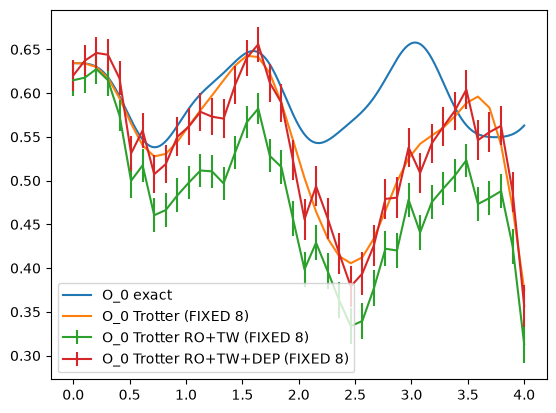

In [43]:
plt.plot(times, zobs_results[:,0], label="O_0 exact")
plt.plot(fs_times, fs_trott_zobs_results[1,:,0], label="O_0 Trotter (FIXED 8)")
plt.errorbar(times_cfs, zobs_8_noise_ro_tw[:,0], err_zobs_8_noise_ro_tw[:,0], label="O_0 Trotter RO+TW (FIXED 8)")
plt.errorbar(times_cfs, zobs_8_noise_ro_tw[:,0]/dep_fact[:,0], err_zobs_8_noise_ro_tw[:,0]/dep_fact[:,0], label="O_0 Trotter RO+TW+DEP (FIXED 8)")

plt.legend()
plt.show()